# US Accidents Exploratory Data Ananlysis 

- data from Kaggle, the dataset is big dataset with 7.7 Mi records.
- target is to clean, analyze and visualize the data
- find interesting findings and answer the questions

## Questions

1. Are there more accidents in Warmer or Colder area ?
2. which 5 states have highest number of accidents?
3. Accidents per capita ?
4. Does new york show up in the data? why is the count so less for accidents in new york ?
5. Among the top 100 cities in number of accident, which states they belong to most frequently ?
6. What time of the day are accident more frequent?
7. which day of the week are accident more frequent ?
8. which month of the year are accidents more frequent?
9. what is the trend of accident year over year?
10. accident by state ?
11. when is accident per unit of traffic high ?
12. is the distribution of accident same on weekend as accident on weekdays
13. can you explain the trend of month wise accident?

## Dependencies

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Download the dataset

- using pandas dataframe we load the data
- being big dataset it took sometime for the commands to execute
- we can also use chunking technqiue to reduce the processing time
- Sampling is used along the project to plot 10% of data for faster processing
- Pandas is of great help when it comes to big dataset as compared to excel.



In [8]:
data = pd.read_csv("/kaggle/input/datasets/sobhanmoosavi/us-accidents/US_Accidents_March23.csv")
data.head(5)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [4]:
data.shape

(7728394, 46)

In [4]:
data.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [6]:
for i in range(6):
    print(i, data['Weather_Condition'][i])

0 Light Rain
1 Light Rain
2 Overcast
3 Mostly Cloudy
4 Mostly Cloudy
5 Light Rain


## Data Preparations and Cleaning

In [5]:
data.isnull().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

In [8]:
data.isnull().sum().sum()

np.int64(12840498)

In [9]:
data.isna().sum().sum()

np.int64(12840498)

In [10]:
data.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [11]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64' ]
numeric_data = data.select_dtypes(include = numerics)
len(numeric_data.columns)

13

In [12]:
numeric_data

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
0,3,39.865147,-84.058723,NaN,NaN,0.010,36.9,NaN,91.0,29.68,10.0,NaN,0.02
1,2,39.928059,-82.831184,NaN,NaN,0.010,37.9,NaN,100.0,29.65,10.0,NaN,0.00
2,2,39.063148,-84.032608,NaN,NaN,0.010,36.0,33.3,100.0,29.67,10.0,3.5,NaN
3,3,39.747753,-84.205582,NaN,NaN,0.010,35.1,31.0,96.0,29.64,9.0,4.6,NaN
4,2,39.627781,-84.188354,NaN,NaN,0.010,36.0,33.3,89.0,29.65,6.0,3.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7728389,2,34.002480,-117.379360,33.99888,-117.37094,0.543,86.0,86.0,40.0,28.92,10.0,13.0,0.00
7728390,2,32.766960,-117.148060,32.76555,-117.15363,0.338,70.0,70.0,73.0,29.39,10.0,6.0,0.00
7728391,2,33.775450,-117.847790,33.77740,-117.85727,0.561,73.0,73.0,64.0,29.74,10.0,10.0,0.00
7728392,2,33.992460,-118.403020,33.98311,-118.39565,0.772,71.0,71.0,81.0,29.62,10.0,8.0,0.00


## Handling missing value

In [6]:
data.isna().sum().sort_values(ascending = False)

End_Lng                  3402762
End_Lat                  3402762
Precipitation(in)        2203586
Wind_Chill(F)            1999019
Wind_Speed(mph)           571233
Visibility(mi)            177098
Wind_Direction            175206
Humidity(%)               174144
Weather_Condition         173459
Temperature(F)            163853
Pressure(in)              140679
Weather_Timestamp         120228
Sunrise_Sunset             23246
Civil_Twilight             23246
Astronomical_Twilight      23246
Nautical_Twilight          23246
Airport_Code               22635
Street                     10869
Timezone                    7808
Zipcode                     1915
City                         253
Description                    5
ID                             0
Distance(mi)                   0
Start_Lng                      0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
County    

In [14]:
missing_percentage = round(data.isna().sum().sort_values(ascending = False) / len(data) *100, 2)


In [20]:
missing_percentage

End_Lng                  44.03
End_Lat                  44.03
Precipitation(in)        28.51
Wind_Chill(F)            25.87
Wind_Speed(mph)           7.39
Visibility(mi)            2.29
Wind_Direction            2.27
Humidity(%)               2.25
Weather_Condition         2.24
Temperature(F)            2.12
Pressure(in)              1.82
Weather_Timestamp         1.56
Sunrise_Sunset            0.30
Civil_Twilight            0.30
Astronomical_Twilight     0.30
Nautical_Twilight         0.30
Airport_Code              0.29
Street                    0.14
Timezone                  0.10
Zipcode                   0.02
City                      0.00
Description               0.00
ID                        0.00
Distance(mi)              0.00
Start_Lng                 0.00
Source                    0.00
Severity                  0.00
Start_Time                0.00
End_Time                  0.00
Start_Lat                 0.00
County                    0.00
Amenity                   0.00
Country 

In [7]:
data.dropna(inplace = True)

In [8]:
data.shape

(3554549, 46)

In [9]:
print("Data lost in cleaning missing values and null values")
print(7728394-3554549) 
print("percentage % loss is")
print(round(4173845/7728394 * 100,2))

Data lost in cleaning missing values and null values
4173845
percentage % loss is
54.01


## Exploratory Data Analysis and Visualization



In [10]:
data.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')

In [3]:
columns_to_work_on = ['Severity','Distance(mi)','City','Start_Time','Start_Lat',
       'Start_Lng','Temperature(F)', 'Weather_Condition']

In [18]:
data1 = data[columns_to_work_on]

In [19]:
data1.shape

(3554549, 8)

In [25]:
len(data.City.unique())


10327

In [33]:
cities_by_accident = data.City.value_counts()
cities_by_accident[:40]

City
Miami              142575
Los Angeles         79444
Orlando             74911
Dallas              50074
Houston             46197
Charlotte           40228
San Diego           32473
Raleigh             31438
Nashville           28555
Sacramento          28421
Baton Rouge         26963
Minneapolis         26649
Austin              25101
Richmond            22524
New Orleans         22323
Phoenix             21595
Tucson              21094
Atlanta             20652
Portland            20343
Saint Paul          19374
Jacksonville        18290
Kansas City         16821
Bakersfield         15884
Riverside           15831
Hialeah             14481
Washington          14412
Bronx               14252
San Bernardino      13390
Columbia            13328
Chattanooga         12417
Ontario             12275
Tampa               12231
Fresno              11942
Rochester           11741
Fort Lauderdale     11628
Anaheim             11587
New York            11203
Salt Lake City      11156
Greenvi

<Axes: ylabel='City'>

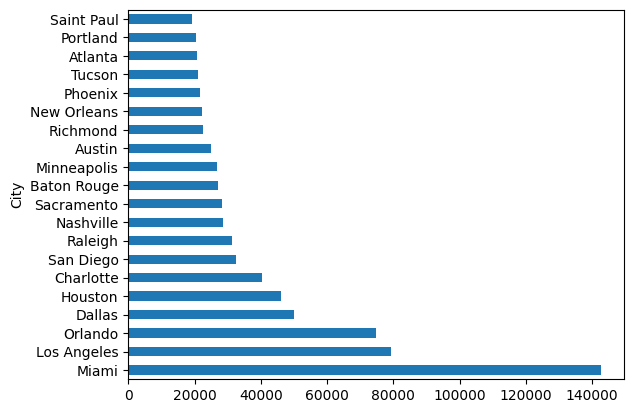

In [35]:
cities_by_accident[:20].plot(kind='barh')

In [36]:
sns.set_style("darkgrid")

<Axes: xlabel='count', ylabel='Count'>

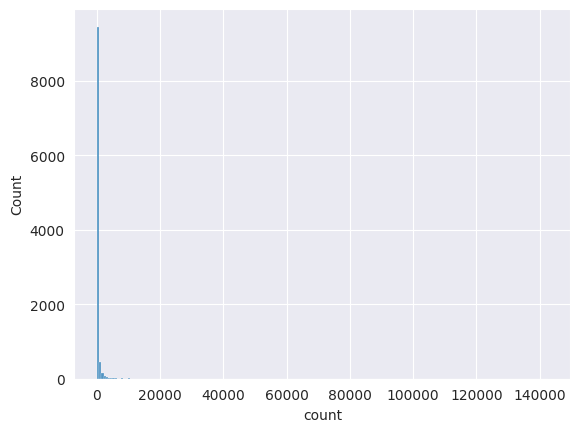

In [40]:
sns.histplot(cities_by_accident)

In [41]:
high_accident_cities = cities_by_accident[cities_by_accident > 1000]
low_accident_cities = cities_by_accident[cities_by_accident <= 1000]

In [47]:
len(high_accident_cities)

615

<Axes: xlabel='count', ylabel='Count'>

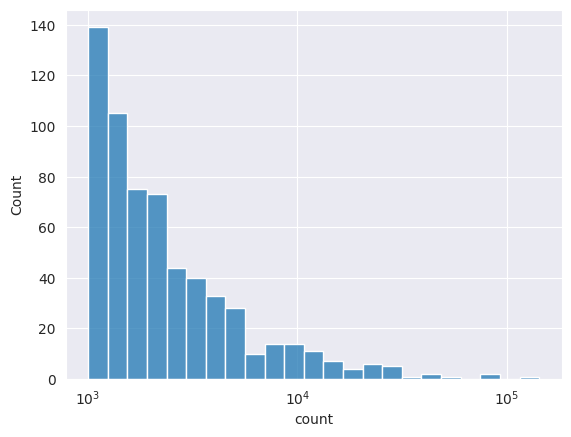

In [54]:
sns.histplot(high_accident_cities, log_scale = True)

<Axes: xlabel='count', ylabel='Count'>

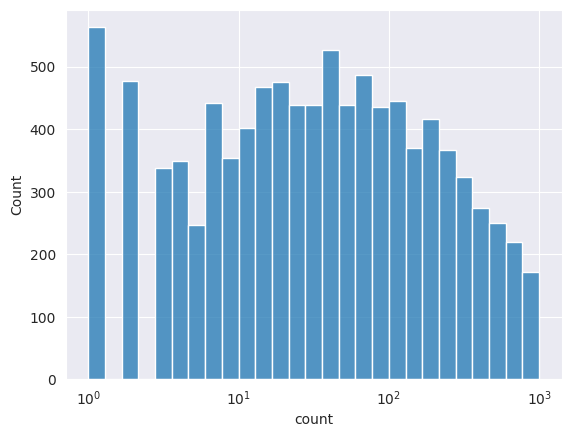

In [55]:
sns.histplot(low_accident_cities, log_scale = True)

In [57]:
cities_with_one_accident = cities_by_accident[cities_by_accident == 1]

In [63]:
len(cities_with_one_accident)

563

In [4]:
columns_to_work_on

['Severity',
 'Distance(mi)',
 'City',
 'Start_Time',
 'Start_Lat',
 'Start_Lng',
 'Temperature(F)',
 'Weather_Condition']

In [16]:
data['Start_Time'] = pd.to_datetime(data['Start_Time'], format='ISO8601')

In [20]:
data.Start_Time.dtype

dtype('<M8[ns]')

In [23]:
data['Hour'] = data['Start_Time'].dt.hour

<Axes: xlabel='Hour', ylabel='Count'>

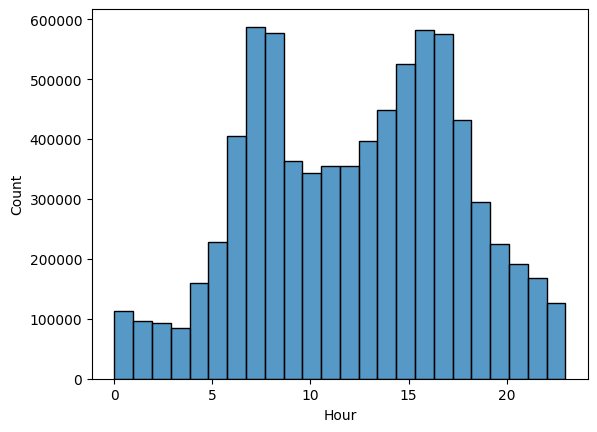

In [25]:
sns.histplot(data.Hour, bins = 24)

In [28]:
data['day'] = data['Start_Time'].dt.dayofweek

<Axes: xlabel='day', ylabel='Count'>

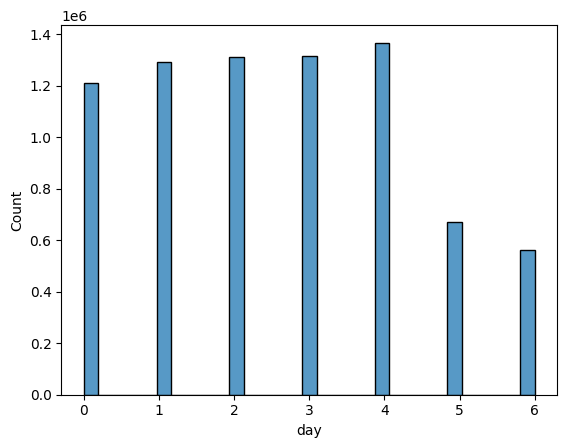

In [31]:
sns.histplot(data.day, bins = 31)

/tmp/ipykernel_12/2262673663.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sunday_start_time.dt.hour, bins = 24, kde = True, norm_hist = True)


<Axes: xlabel='Start_Time', ylabel='Density'>

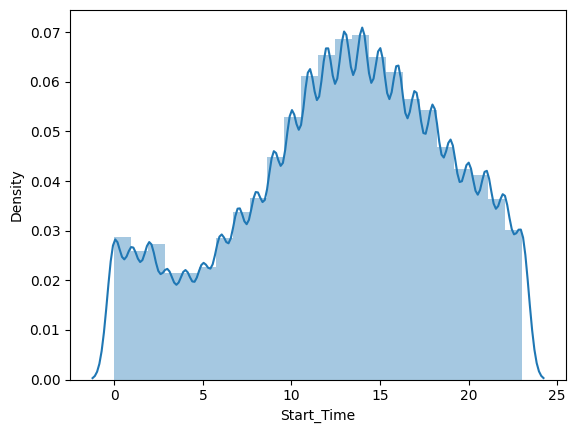

In [44]:
sunday_start_time = data.Start_Time[data.Start_Time.dt.dayofweek == 5]
sns.distplot(sunday_start_time.dt.hour, bins = 24, kde = True, norm_hist = True)

/tmp/ipykernel_12/3906393855.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(monday_start_time.dt.hour, bins = 24, kde = True, norm_hist = True)


<Axes: xlabel='Start_Time', ylabel='Density'>

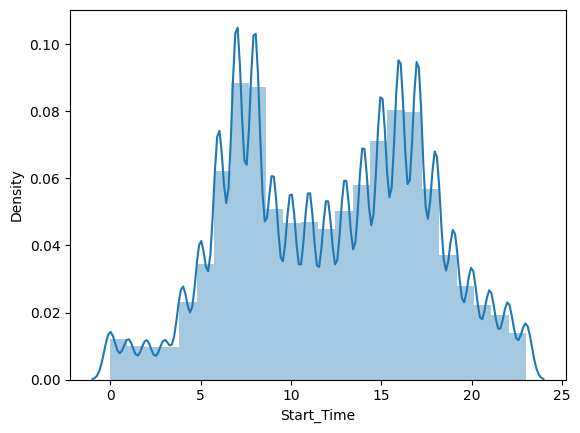

In [45]:
monday_start_time = data.Start_Time[data.Start_Time.dt.dayofweek == 0]
sns.distplot(monday_start_time.dt.hour, bins = 24, kde = True, norm_hist = True)

In [46]:
data.Start_Time.dtype

dtype('<M8[ns]')

<Axes: xlabel='Start_Time', ylabel='Count'>

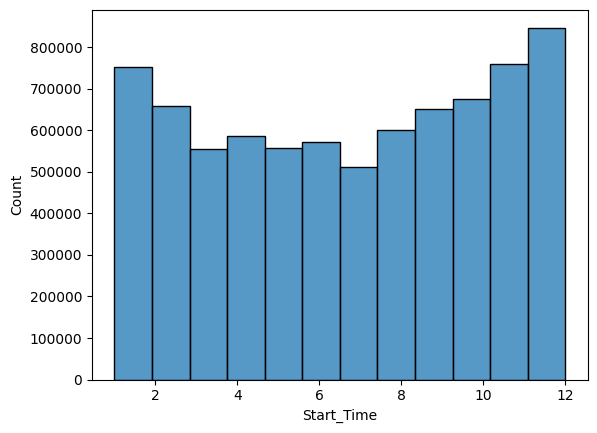

In [51]:
sns.histplot(data.Start_Time.dt.month, bins = 12)

In [61]:
data_2019 = data[data.Start_Time.dt.year == 2020]

/tmp/ipykernel_12/1468507761.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2019.Start_Time.dt.month, bins = 12)


<Axes: xlabel='Start_Time', ylabel='Density'>

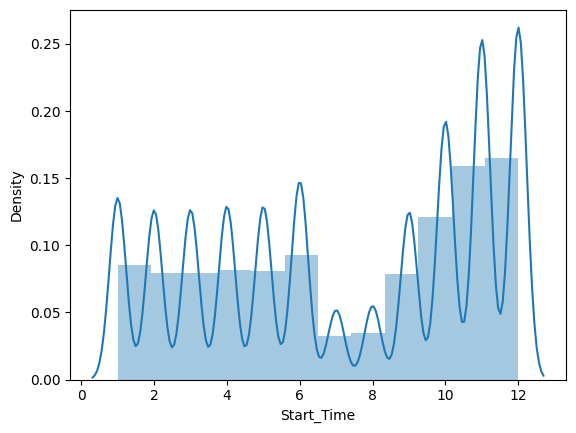

In [62]:
sns.distplot(data_2019.Start_Time.dt.month, bins = 12)

<Axes: >

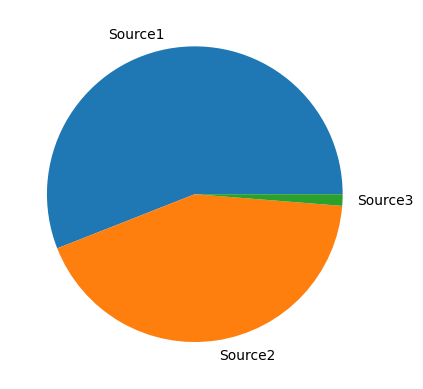

In [63]:
data.Source.value_counts().plot(kind = 'pie')

- Consider excluding Bing data, seems to have issue

## Start Latitude & Longitude

In [64]:
data.Start_Lat

0          39.865147
1          39.928059
2          39.063148
3          39.747753
4          39.627781
             ...    
7728389    34.002480
7728390    32.766960
7728391    33.775450
7728392    33.992460
7728393    34.133930
Name: Start_Lat, Length: 7728394, dtype: float64

In [65]:
data.Start_Lng

0          -84.058723
1          -82.831184
2          -84.032608
3          -84.205582
4          -84.188354
              ...    
7728389   -117.379360
7728390   -117.148060
7728391   -117.847790
7728392   -118.403020
7728393   -117.230920
Name: Start_Lng, Length: 7728394, dtype: float64

In [71]:
sample_data = data.sample(int(0.1 * len(data)))


<Axes: xlabel='Start_Lng', ylabel='Start_Lat'>

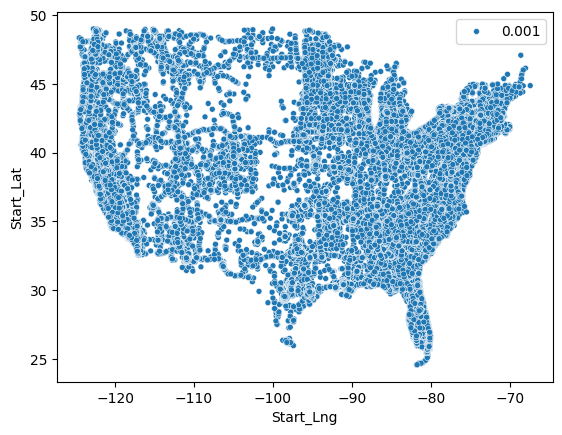

In [72]:
sns.scatterplot(x = sample_data.Start_Lng, y = sample_data.Start_Lat, size = 0.001)

In [74]:
pip install folium


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [75]:
import folium

In [84]:
lat,lng = data.Start_Lat[0:1000], data.Start_Lng[0:1000]

In [94]:
lat_lng_points = [
    (row.Start_Lat, row.Start_Lng)
    for row in data[['Start_Lat','Start_Lng']]
        .sample(100)
        .itertuples(index=False)
]

In [95]:
print(lat_lng_points)

[(33.900024, -117.473351), (37.152472, -119.731458), (35.39098, -97.424507), (40.744457, -78.200073), (39.814262, -84.130081), (30.48625, -81.871887), (32.179373502577874, -110.90763688034578), (35.83414000000001, -78.76903), (40.066805, -75.10594300000002), (28.49405800000001, -81.456405), (34.4925, -118.19505), (38.625931, -121.517159), (28.114674, -82.739997), (40.480679, -77.04907), (35.201922654937725, -82.85612940748759), (38.656441, -77.279388), (36.61976, -119.78612), (34.076518, -80.96758299999998), (45.29850840546942, -122.65899538935344), (35.016762, -81.960983), (33.900959, -81.511078), (33.930722, -118.210617), (40.842827, -73.82558399999998), (40.10484, -74.89973), (42.49620079973938, -83.5271966453384), (29.669153, -95.262543), (34.819962, -82.25636300000002), (38.79232, -90.452263), (44.78923, -95.158653), (39.018726, -76.975487), (41.825726, -71.419106), (37.62505, -120.922928), (25.8333, -80.206284), (33.435112, -82.00993299999998), (39.84037, -86.083832), (40.2271, -

In [98]:
from folium.plugins import HeatMap

In [101]:
map = folium.Map()
HeatMap(lat_lng_points).add_to(map)
map

## Summary and Conclusions

1. 615 Cities out of 10327 have high amount of accident, that is around 5.95%.
2. 563 cities have just 1 accident reported
3. The number of accidents per city decreases exponentially
4. a high percentage of accidents occurs between 6 to 10 AM (probably people in hurry for work)
5. 3 to 6 PM are lot of accidents happens (probably people leaving for home, high traffic)
6. There are more accidents in Winters probably due to snow problem and skitting